In [20]:

import numpy as np
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
from DecayFitNet.python.toolbox.DecayFitNetToolbox import DecayFitNetToolbox

from slope2noise.utils import *

Here we are testing the code used to generate impulse responses by shaping white gaussian noise.   
The envelope is adjusted to match a target EDC, following the common slope model.  
First, define the T and A energy decay parameters (in the Schroeder backward integration sense)


In [21]:
T_s = np.array([[0.5, 1.5]])  # T60 in seconds
A_s = np.array([2, 0.1])   # decay model amplitude (energy)
n_slopes = T_s.shape[-1]
fs = 48000  # sampling frequency in Hz
L = 3*fs   # length of the impulse response in samples

time_axis = np.arange(0, L) / fs

### Target Energy Decay Curve 
Construct the EDC of the desired RIR from the T_s and A_s values

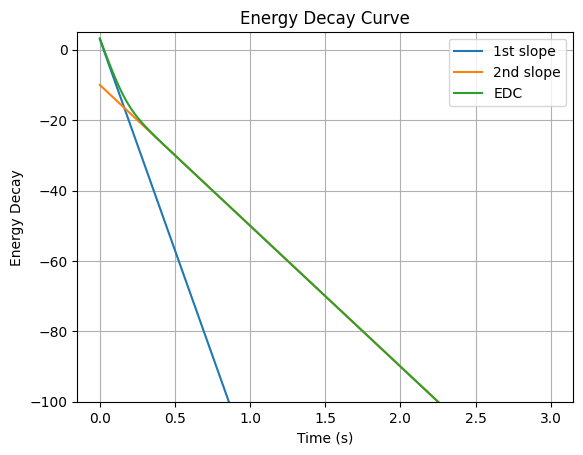

In [22]:
envelope_kernel = decay_kernel( T_s,
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc = A_s*envelope_kernel
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.ylim([-100, 5])
plt.grid(True)
plt.show()

### Shaped Noise
Here the Schroeder T and A values are adapted and used to define the envelopes, which are then multiplied with the wgn


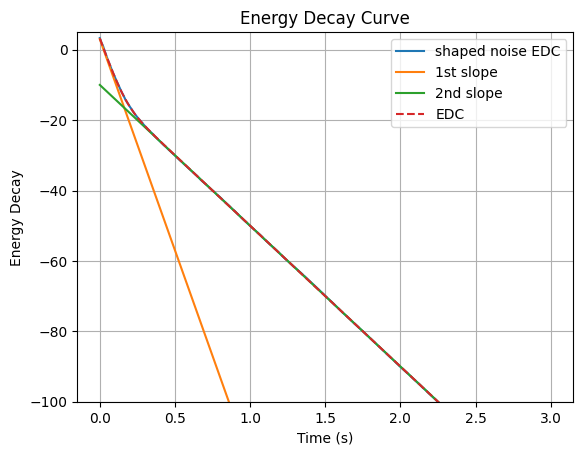

In [23]:
T_e = 2 * T_s
envelope_kernel = decay_kernel( T_e,
                                time_axis,
                                fs,
                                normalize_envelope=True,
                                add_noise=False)
gaussian_noise = np.random.randn(1, L, n_slopes)
shaped_noise = np.sqrt(A_s)*envelope_kernel*gaussian_noise
# use schroeder backward integration to get the EDC
sn_int = schroeder_backward_int(np.sum(shaped_noise, axis=-1), normalize=False)
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.ylim([-100, 5])
plt.grid(True)
plt.show()

Let's double check with linear least squares that we are producing an RIR with correct A values.  
Let's also use BDA to confirm that the shaped noise has the target EDC. BDA estimated both T_s and A_s. 

In [24]:
A_ls = calculate_amplitudes_least_squares(T_s,
                                          fs,
                                          np.sum(shaped_noise, axis=-1, keepdims=True),
                                          f_bands=None,
                                          leave_out_ms=50.0,
                                          )

BDA = bda.BayesianDecayAnalysis(n_slopes,
                                fs,
                                filter_frequencies=None, )
decayfitnet = DecayFitNetToolbox(n_slopes,
                                fs,
                                filter_frequencies=None, )
# shaped_noise = shaped_noise/np.sum(shaped_noise**2)
edc_param, norm_vals = BDA.estimate_parameters(np.sum(shaped_noise,-1))
# edc_param, norm_vals = decayfitnet.estimate_parameters(np.sum(shaped_noise,-1), analyse_full_rir=True)
# norm_vals = np.transpose(norm_vals.numpy())
norm_vals = np.transpose(norm_vals)
# BDA takes the EDC parameters estimates for each band
T, A, N = edc_param[0], edc_param[1], edc_param[2]
# amplitudes with least squares
print(
    f"Estimated T_BDA: \n {np.median(np.squeeze(np.round(T, 3)), axis=0)}, \nA_BDA: \n {np.squeeze(np.round(A, 3))} \n" \
    f"Estimated A_LS: {np.squeeze(np.round(A_ls, 3))} \n" \
    f"Reference T: {np.squeeze(np.round(T_s, 3))}, A: {np.squeeze(np.round(A_s, 3))}"
)
print(
    f"Noise level: \n {N}")
print(
    f"Normalization values: \n {norm_vals}")

Estimated T_BDA: 
 [0.7865 1.422 ], 
A_BDA: 
 [[1.    0.081]
 [0.498 0.175]
 [0.008 0.201]
 [0.811 0.017]
 [0.305 0.005]
 [0.285 0.053]] 
Estimated A_LS: [1.36  0.064] 
Reference T: [0.5 1.5], A: [2.  0.1]
Noise level: 
 [[6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]]
Normalization values: 
 [[0.0096174 ]
 [0.01422393]
 [0.02951635]
 [0.07153738]
 [0.1497916 ]
 [0.2461048 ]]


Generate the EDC from the BDA estimations 

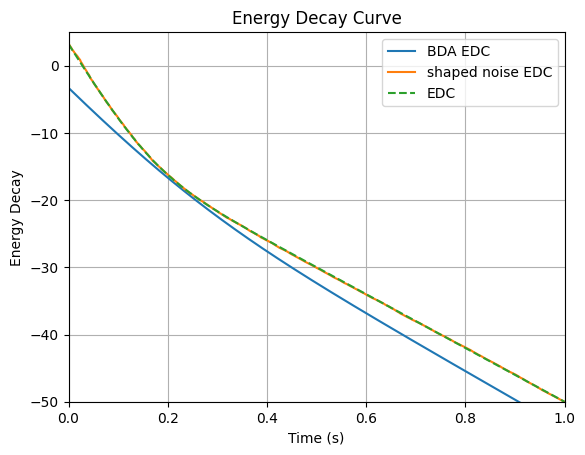

In [25]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

what if we "denormalize" the A values that BDA is estimating?  
Note that since we are working on synthetic data, the noise component is negligible 

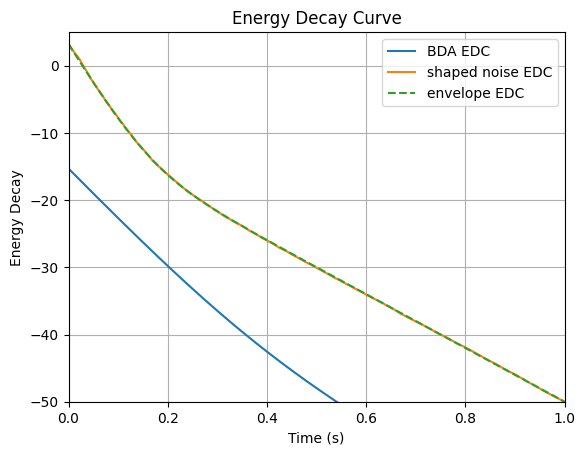

In [26]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A * norm_vals, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

Maybe we need to compensate for the energy of the octave filter bank? 
The results look much better if we do so! 

In [29]:
A_n = A * norm_vals
# Estimate the energy of the octave filters
rirFBands, _ = octave_filtering([], 
                             fs, 
                             BDA.get_filter_frequencies(), 
                             ir_len=L,
                             get_filter_ir=True)
bandEnergy = np.expand_dims(sum(np.abs(rirFBands)**2, 0), -1)  
# initial level
A_n =  A_n / bandEnergy
print(A_n) 

[[4.44898805 0.36087114]
 [1.63743263 0.57493399]
 [0.02768858 0.6858672 ]
 [3.35546212 0.07229124]
 [1.3227549  0.02311552]
 [1.01381064 0.1899696 ]]


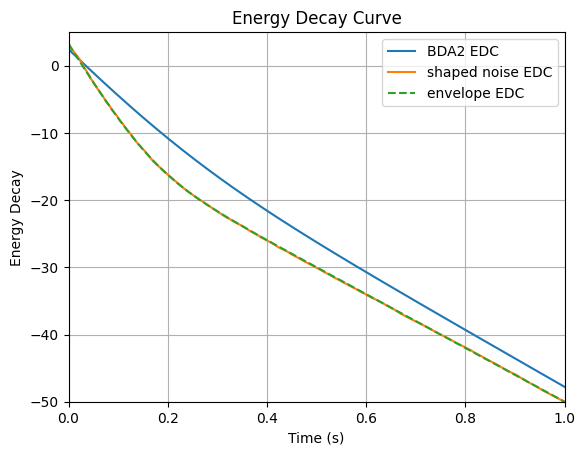

In [28]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_n, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA2 EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()